Loading Hugging Face ViT model...


Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

 Using device: CPU
 Initializing GlassBox-ViT (GradCamExplainer)...
 Loading and resizing test image (Chelsea the cat)...
 Generating Grad-CAM Explanation (Extracting gradients)...

 EXPLANATION GENERATED SUCCESSFULLY!
-> Model Prediction: Egyptian cat (97.55%)
-> Class Explained in Heatmap: Egyptian cat


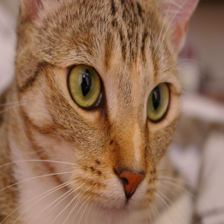

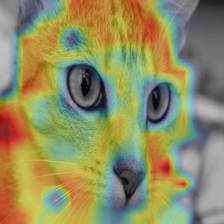


 Generating Counterfactual Explanation (Target: Dog)...


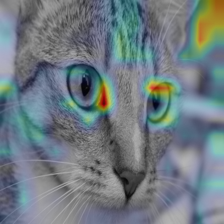

In [ ]:
from IPython.display import display
import torch
import numpy as np
from PIL import Image
from transformers import AutoImageProcessor, AutoModelForImageClassification
from skimage import data

# Import your custom library
from glassbox_vit.gradcam_explainer import GradCamExplainer

# --- MODEL SETUP ---
print("Loading Hugging Face ViT model...")
model_name = "google/vit-base-patch16-224"
processor = AutoImageProcessor.from_pretrained(model_name)
model = AutoModelForImageClassification.from_pretrained(model_name)

# Set device automatically
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f" Using device: {device.upper()}")

# Extract class names from the model config
class_names = list(model.config.id2label.values())

# --- 2. INITIALIZE EXPLAINER ---
print(" Initializing GlassBox-ViT (GradCamExplainer)...")
# White-Box Explainer: We pass the model and processor directly!
gradcam_explainer = GradCamExplainer(
    model=model,
    processor=processor
)

# --- LOAD TEST IMAGE ---
print(" Loading and resizing test image (Chelsea the cat)...")
image_np = data.chelsea()
# ViT models expect 224x224 images
test_image = Image.fromarray(image_np).convert("RGB").resize((224, 224))

# ---  GENERATE EXPLANATION ---
print(" Generating Grad-CAM Explanation (Extracting gradients)...")
# By default, it explains the class that the model is most confident about
result = gradcam_explainer.generate(pil_image=test_image)

# ---  DISPLAY RESULTS ---

# Extract final metrics (Notice the 4 extracted variables!)
predicted_class = class_names[result['predicted_label_id']]
explained_class = class_names[result['explained_label_id']]
confidence = result['prediction_prob'] * 100

print("\n EXPLANATION GENERATED SUCCESSFULLY!")
print(f"-> Model Prediction: {predicted_class} ({confidence:.2f}%)")
print(f"-> Class Explained in Heatmap: {explained_class}")
display(test_image)
display(result['gradcam_image'])

# =====================================================================
#  BONUS FEATURE: COUNTERFACTUAL EXPLANATION
# Want to ask the model: "Why didn't you predict this is a Dog?"
# Uncomment the code below to test it!
# =====================================================================

print("\n Generating Counterfactual Explanation (Target: Dog)...")
# Let's say class 263 is a specific dog breed in ImageNet
dog_class_id = 263
counterfactual_result = gradcam_explainer.generate(
    pil_image=test_image,
    target_class_id=dog_class_id, counterfactual=True
)

display(counterfactual_result['gradcam_image'])
